<h1>E-Commerce Sales Demand Prediction</h1>

<h2>3. Machine Learning for Demand Prediction</h2>
<b>3.0. IMPORT REQUIRED LIBRARIES</b>

In [8]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

<br><b>3.1. LOAD THE CLEANED DATASET</b>

In [9]:
file_path = "E:/Project/ecommerce_sales_demand_prediction/data/processed/ecommerce_sales_cleaned.csv"

df = pd.read_csv(file_path)

# Convert Order Date back to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

print("Cleaned dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

display(df.head())

Cleaned dataset loaded successfully!
Dataset shape: (3500, 12)


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Year,Month,Month Name,Quarter,Day of Week
0,2024-12-31,Printer,Office,North,4,3640,348.93,2024,12,December,4,Tuesday
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,2022,11,November,4,Sunday
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,2022,5,May,2,Wednesday
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,2024,3,March,1,Saturday
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,2022,9,September,3,Saturday


<br><h3>3.2. Define the Prediction Problem</h3>

**Objective**: Predict the quantity of products demanded based on the available product, category, region, and time-related information.

**Target Variable:** `Quantity`

**Features:** Product Name, Category, Region, Year, Month, Quarter, and Day of Week.

The `Quantity` column will be excluded from the input features because it is the value we are trying to predict.

<br>**3.3. PREPARE FEATURES AND TARGET**

In [15]:
# Features used for prediction
features=[
    "Product Name",
    "Category",
    "Region",
    "Year",
    "Month",
    "Quarter",
    "Day of Week"
]

# Create feature matrix and target variable
X=df[features]
y=df["Quantity"]
print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features (X):


,Product Name,Category,Region,Year,Month,Quarter,Day of Week
0,Printer,Office,North,2024,12,4,Tuesday
1,Mouse,Accessories,East,2022,11,4,Sunday
2,Tablet,Electronics,South,2022,5,2,Wednesday
3,Mouse,Accessories,South,2024,3,1,Saturday
4,Mouse,Accessories,West,2022,9,3,Saturday



Target (y):


0    4
1    7
2    5
3    2
4    1
Name: Quantity, dtype: int64


Feature matrix shape: (3500, 7)
Target shape: (3500,)


<br>**3.4. ENCODE CATEGORICAL FEATURES**

In [17]:
categorical_features=[
    "Product Name",
    "Category",
    "Region",
    "Day of Week"
]

numerical_features=[
    "Year",
    "Month",
    "Quarter"
]

preprocessor=ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)
print("Categorical and numerical feature preprocessing defined successfully.")

Categorical and numerical feature preprocessing defined successfully.


## 3.5. Train-Test Split

The dataset is split chronologically into:

- **80% Training Data:** Earlier observations used to train the model.
- **20% Testing Data:** Later observations used to evaluate the model on unseen data.

A chronological split is more appropriate for demand prediction because it better represents a real-world forecasting scenario.

**3.5. CHRONOLOGICAL TRAIN-TEST SPLIT**

In [19]:
# Sort the dataset chronologically
df = df.sort_values("Order Date").reset_index(drop=True)

# Determine the date at the 80% position
split_date = df["Order Date"].iloc[int(len(df) * 0.80)]

# Training data: dates strictly before split date
train_df = df[df["Order Date"] < split_date]

# Testing data: dates on or after split date
test_df = df[df["Order Date"] >= split_date]

# Create X and y
X_train = train_df[features]
X_test = test_df[features]

y_train = train_df["Quantity"]
y_test = test_df["Quantity"]

print("Strict chronological train-test split completed.")

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

print(
    f"\nTraining period: "
    f"{train_df['Order Date'].min().date()} to "
    f"{train_df['Order Date'].max().date()}"
)

print(
    f"Testing period: "
    f"{test_df['Order Date'].min().date()} to "
    f"{test_df['Order Date'].max().date()}"
)

Strict chronological train-test split completed.

Training samples: 2799
Testing samples: 701

Training period: 2022-01-01 to 2024-05-30
Testing period: 2024-05-31 to 2024-12-31


## 3.6. Baseline Model

The baseline model predicts the average product demand observed in the training dataset for every observation in the test dataset.

This provides a simple benchmark against which the machine learning models can be evaluated.

<br>**3.6. BASELINE MODEL**

In [21]:
# Calculate average demand from training data
baseline_prediction = y_train.mean()

# Predict the same average demand for every test observation
y_baseline_pred = np.full(
    shape=len(y_test),
    fill_value=baseline_prediction
)

print(f"Average training demand: {baseline_prediction:.2f}")
print(f"Baseline predictions created: {len(y_baseline_pred)}")

Average training demand: 4.90
Baseline predictions created: 701


### 3.6.1. Baseline Model Evaluation

The baseline model will be evaluated using three regression metrics:

- **MAE (Mean Absolute Error):** Average absolute difference between actual and predicted demand.
- **RMSE (Root Mean Squared Error):** Penalizes larger prediction errors more strongly.
- **R² Score:** Measures how much of the variation in demand is explained by the model.

<br>**3.6.1. BASELINE MODEL EVALUATION**

In [22]:
baseline_mae = mean_absolute_error(y_test, y_baseline_pred)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, y_baseline_pred)
)

baseline_r2 = r2_score(
    y_test,
    y_baseline_pred
)

print("Baseline Model Performance")
print("-" * 35)
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline Model Performance
-----------------------------------
MAE  : 2.1909
RMSE : 2.5514
R²   : -0.0042


## LINEAR REGRESSION MODEL

**3.7. TRAIN & EVALUATE LINEAR REGRESSION**

In [25]:
# ============================================
# TRAIN LINEAR REGRESSION
# ============================================
linear_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_regression_pipeline.fit(X_train, y_train)

# Generate predictions
y_linear_pred = linear_regression_pipeline.predict(X_test)

print("Linear Regression model trained successfully.")
print(f"Predictions generated: {len(y_linear_pred)}")

# ============================================
# LINEAR REGRESSION EVALUATION
# ============================================

linear_mae = mean_absolute_error(y_test, y_linear_pred)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, y_linear_pred)
)

linear_r2 = r2_score(
    y_test,
    y_linear_pred
)

print("\nLinear Regression Performance")
print("-" * 35)
print(f"MAE  : {linear_mae:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression model trained successfully.
Predictions generated: 701

Linear Regression Performance
-----------------------------------
MAE  : 2.2170
RMSE : 2.5798
R²   : -0.0267


## RANDOM FOREST MODEL

**3.8. TRAIN & EVALUATE RANDOM FOREST REGRESSOR**

In [30]:
# ============================================
# TRAIN RANDOM FOREST REGRESSOR
# ============================================

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_pipeline.fit(X_train, y_train)

# Generate predictions
y_rf_pred = random_forest_pipeline.predict(X_test)

print("Random Forest Regressor trained successfully.")
print(f"Predictions generated: {len(y_rf_pred)}")

# ============================================
# RANDOM FOREST EVALUATION
# ============================================

rf_mae = mean_absolute_error(y_test, y_rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_rf_pred)
)

rf_r2 = r2_score(
    y_test,
    y_rf_pred
)

print("\nRandom Forest Performance")
print("-" * 35)
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Regressor trained successfully.
Predictions generated: 701

Random Forest Performance
-----------------------------------
MAE  : 2.3575
RMSE : 2.7758
R²   : -0.1886


**3.9. MODEL PERFORMANCE COMPARISON**

In [32]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

# Display rounded results
display(
    model_comparison.round(4)
)

,Model,MAE,RMSE,R2 Score
0,Baseline,2.1909,2.5514,-0.0042
1,Linear Regression,2.2170,2.5798,-0.0267
2,Random Forest,2.3575,2.7758,-0.1886


<br>**3.10. RANDOM FOREST FEATURE IMPORTANCE**

,Feature,Importance
0,numerical__Month,0.222352
1,numerical__Year,0.101697
2,numerical__Quarter,0.046480
3,categorical__Region_South,0.038157
4,categorical__Region_West,0.036891
5,categorical__Region_North,0.035170
6,categorical__Day of Week_Sunday,0.032722
7,categorical__Day of Week_Thursday,0.032309
8,categorical__Region_East,0.032304
9,categorical__Day of Week_Tuesday,0.031310


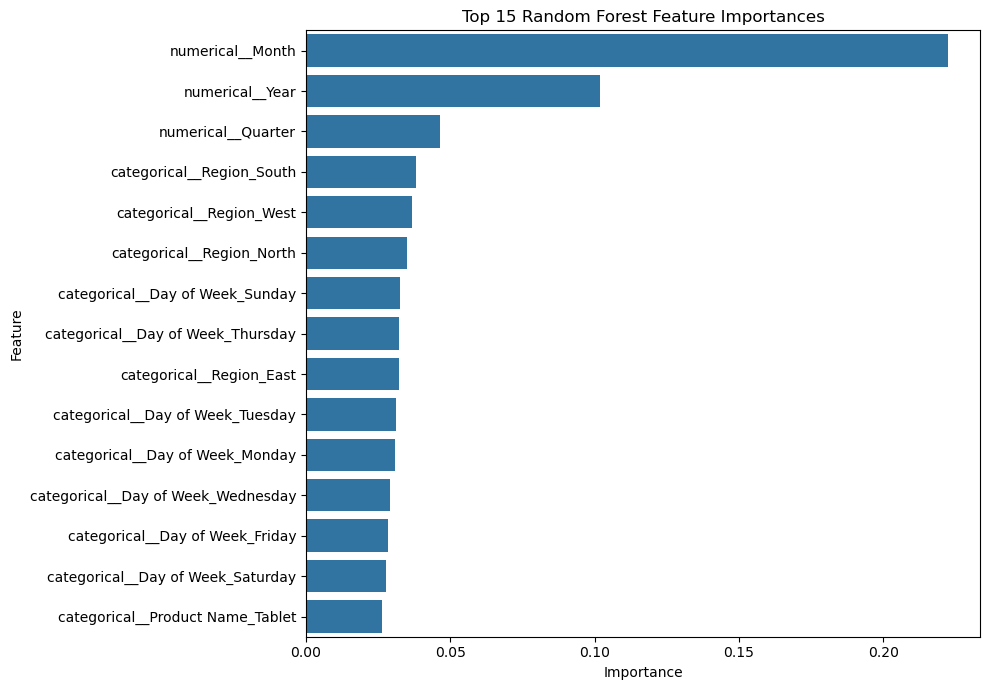

In [34]:
# Get the fitted preprocessor
fitted_preprocessor = random_forest_pipeline.named_steps["preprocessor"]

# Get the trained Random Forest model
rf_model = random_forest_pipeline.named_steps["model"]

# Get names of all transformed features
encoded_feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance values
feature_importance = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

# Display all feature importances
display(feature_importance)

# Plot top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Business Interpretation

The Random Forest model assigned the highest individual importance to Month (0.2224), followed by Year (0.1017) and Quarter (0.0465). This indicates that time-related features contributed more to the model's decision-making than most individual product and category features.

Region and day-of-week features also contributed to the model, while individual product and category features generally had lower importance.

However, these feature importance values should be interpreted alongside the model's performance. Since the Random Forest achieved an R² score of -0.1886 and performed worse than the baseline, the available features do not provide sufficient predictive information for accurately predicting individual product demand.

<br>**3.11. ACTUAL VS PREDICTED DEMAND**

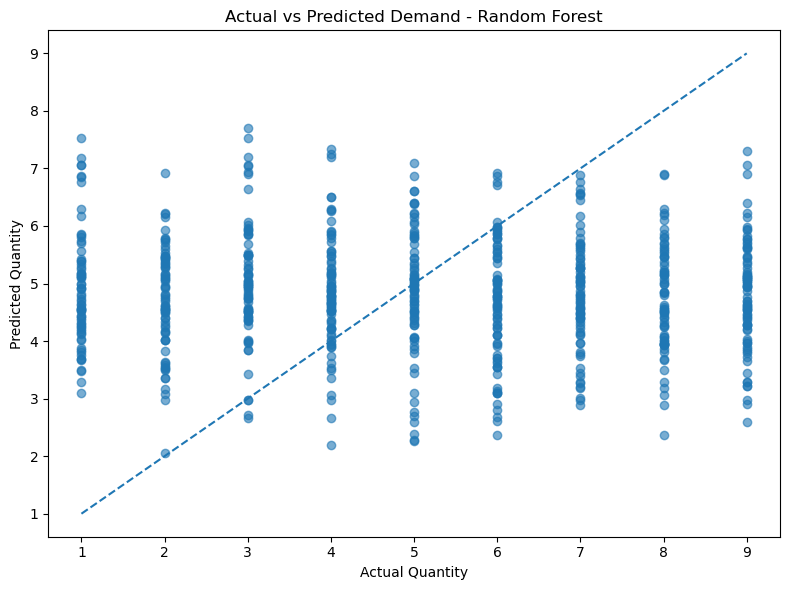

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_rf_pred,
    alpha=0.6
)

# Perfect prediction reference line
min_value = min(y_test.min(), y_rf_pred.min())
max_value = max(y_test.max(), y_rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Demand - Random Forest")
plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")

plt.tight_layout()
plt.show()

### Business Interpretation

The Actual vs Predicted plot shows that the Random Forest predictions are concentrated around the middle range of demand values rather than closely following the actual quantities.

The model tends to underestimate higher-demand observations and overestimate some lower-demand observations. This explains the relatively high prediction errors and the negative R² score of -0.1886.

The visualization confirms that the current features are not sufficient to accurately predict individual product demand. Additional historical demand, pricing, promotions, inventory, and other business-related variables could potentially improve future model performance.

## 3.12. Save Trained Models

In [37]:
import os

# Create models directory if it does not exist
os.makedirs("E:/Project/ecommerce_sales_demand_prediction/models", exist_ok=True)

# File paths
linear_model_path = "E:/Project/ecommerce_sales_demand_prediction/models/linear_regression_demand_model.pkl"
random_forest_model_path = "E:/Project/ecommerce_sales_demand_prediction/models/random_forest_demand_model.pkl"

# Save Linear Regression pipeline
joblib.dump(
    linear_regression_pipeline,
    linear_model_path
)

# Save Random Forest pipeline
joblib.dump(
    random_forest_pipeline,
    random_forest_model_path
)

print("Models saved successfully!")
print(f"Linear Regression: {linear_model_path}")
print(f"Random Forest: {random_forest_model_path}")

Models saved successfully!
Linear Regression: E:/Project/ecommerce_sales_demand_prediction/models/linear_regression_demand_model.pkl
Random Forest: E:/Project/ecommerce_sales_demand_prediction/models/random_forest_demand_model.pkl


## 3.13. Final Model Summary

### Model Performance

The three approaches were evaluated using MAE, RMSE, and R² Score.

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Baseline | 2.1909 | 2.5514 | -0.0042 |
| Linear Regression | 2.2170 | 2.5798 | -0.0267 |
| Random Forest | 2.3575 | 2.7758 | -0.1886 |

### Key Findings

1. The **Baseline model performed better** than both machine learning models on the test data.
2. Linear Regression achieved an MAE of **2.2170**, which was slightly worse than the baseline MAE of **2.1909**.
3. Random Forest achieved an MAE of **2.3575** and an R² score of **-0.1886**, making it the weakest of the three approaches.
4. The Random Forest feature importance analysis showed that **Month** was the most important individual feature, followed by **Year** and **Quarter**.
5. The Actual vs Predicted visualization showed that Random Forest predictions were concentrated around the middle demand range instead of closely following actual demand.
6. The negative R² scores indicate that the current features do not adequately explain variation in individual product demand.

### Business Conclusion

The current dataset is suitable for sales analysis and exploratory analysis, but it does not contain enough predictive information to build a strong individual demand prediction model.

Important variables that could improve future demand prediction include:

- Historical demand / lag features
- Product price
- Discounts
- Promotions
- Inventory availability
- Marketing campaigns
- Holidays and seasonal events
- Competitor pricing

Therefore, the current machine learning results should be reported honestly rather than presenting the models as highly accurate demand predictors.

In [40]:
# ============================================
#FINAL MODEL SUMMARY
# ============================================

best_model = model_comparison.loc[
    model_comparison["MAE"].idxmin()
]

print("FINAL DEMAND PREDICTION SUMMARY")
print("=" * 45)

print(f"Best performing approach: {best_model['Model']}")
print(f"MAE : {best_model['MAE']:.4f}")
print(f"RMSE: {best_model['RMSE']:.4f}")
print(f"R²  : {best_model['R2 Score']:.4f}")

print("\nKey Conclusion:")
print(
    "The baseline model outperformed both machine learning models. "
    "The current features are insufficient for accurately predicting "
    "individual product demand."
)

FINAL DEMAND PREDICTION SUMMARY
Best performing approach: Baseline
MAE : 2.1909
RMSE: 2.5514
R²  : -0.0042

Key Conclusion:
The baseline model outperformed both machine learning models. The current features are insufficient for accurately predicting individual product demand.
